# SMPL Human Body → Radar Simulation

**Pipeline:**
1. Scene places an SMPL body mesh with lighting
2. Renderer ray-traces the scene → reflection points + intensities
3. Radar (Dirichlet solver) generates a full MIMO frame
4. Signal processing extracts a 3D point cloud

**Requires:** smplpytorch, mitsuba (cuda_ad_rgb variant)

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parents[0] / "witwin-radar"))

import numpy as np
import torch
import matplotlib.pyplot as plt
from core import Radar, Renderer, Scene
from sigproc import process_pc, process_rd

torch.set_default_device('cuda')

c:\Users\Asixa\miniconda3\envs\witwin2\Lib\site-packages\slangtorch\slangtorch.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
jitc_llvm_init(): LLVM API initialization failed ..


## 1. Radar Config (TI IWR1843)

In [2]:
config = {
    "num_tx": 3, "num_rx": 4,
    "fc": 77e9,
    "slope": 60.012,
    "adc_samples": 256,
    "adc_start_time": 6,
    "sample_rate": 4400,
    "idle_time": 7,
    "ramp_end_time": 65,
    "chirp_per_frame": 128,
    "frame_per_second": 10,
    "num_doppler_bins": 128,
    "num_range_bins": 256,
    "num_angle_bins": 64,
    "power": 15,
    "tx_loc": [[0, 0, 0], [4, 0, 0], [2, 1, 0]],
    "rx_loc": [[-6, 0, 0], [-5, 0, 0], [-4, 0, 0], [-3, 0, 0]],
}
radar = Radar(config)

c:\Users\Asixa\miniconda3\envs\witwin2\Lib\site-packages\setuptools\_distutils\_msvccompiler.py:12: UserWarning: _get_vc_env is private; find an alternative (pypa/distutils#340)
  warnings.warn(


## 2. Scene: SMPL Body in Front of Radar

In [3]:
scene = Scene(fov=60)
scene.set_sensor(origin=(0, -0.5, 0), target=(0, -0.5, -5))

print("Adding SMPL body to scene...")
pose = np.zeros(72)        # T-pose
shape = np.zeros(10)       # average body shape
scene.add_smpl("human", pose, shape, translation=[0, -1, -3], gender='male')

renderer = Renderer(scene, resolution=128)

Adding SMPL body to scene...


## 3. Ray Trace

In [4]:
points, intensities = renderer.trace()
print(f"{points.shape[0]} reflection points")
print(f"Z range: {points[:, 2].min():.2f} ~ {points[:, 2].max():.2f} m")

799 reflection points
Z range: -3.08 ~ -2.85 m


Image shape: torch.Size([128, 128]), range: [0.0000, 0.7224]


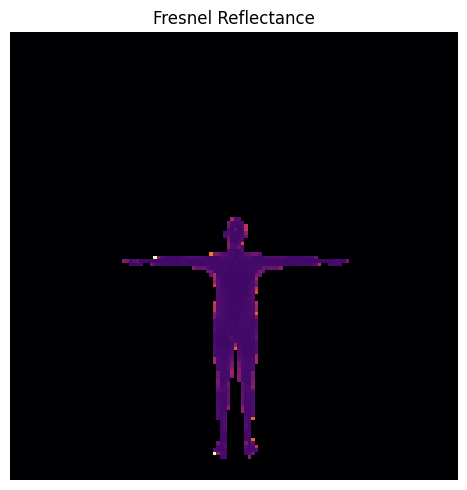

In [5]:
image = renderer.render_image()
print(f"Image shape: {image.shape}, range: [{image.min():.4f}, {image.max():.4f}]")

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(image.cpu().numpy(), cmap='inferno', origin='upper')
ax.set_title('Fresnel Reflectance')
ax.axis('off')
## add a colorbar
plt.tight_layout()

In [6]:
points.shape

torch.Size([799, 3])

## 4. Radar MIMO Frame

In [7]:
velocity = torch.tensor([0, 0, 1], device='cuda')

def location_function(t):
    return intensities*10, points + velocity * t

frame = radar.mimo(location_function, t0=0)
print(f"Frame shape: {frame.shape}  (TX, RX, chirps, ADC)")

Frame shape: torch.Size([3, 4, 128, 256])  (TX, RX, chirps, ADC)


In [8]:
frame.shape

torch.Size([3, 4, 128, 256])

c:\Users\Asixa\miniconda3\envs\witwin2\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\Asixa\miniconda3\envs\witwin2\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


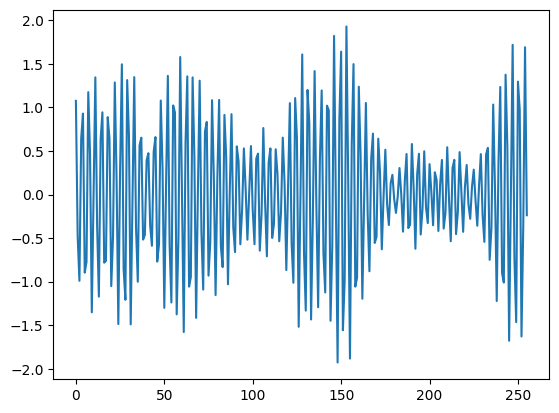

In [9]:
plt.plot(frame[0, 0, 0].cpu().numpy())

## 5. Point Cloud + Range-Doppler

In [10]:
pc = process_pc(radar, frame)
print(f"{pc.shape[0]} detected points")

rd_mag, rd_map, ranges, velocities = process_rd(radar, frame, tx=0, rx=0)

4 detected points


## 6. Visualization

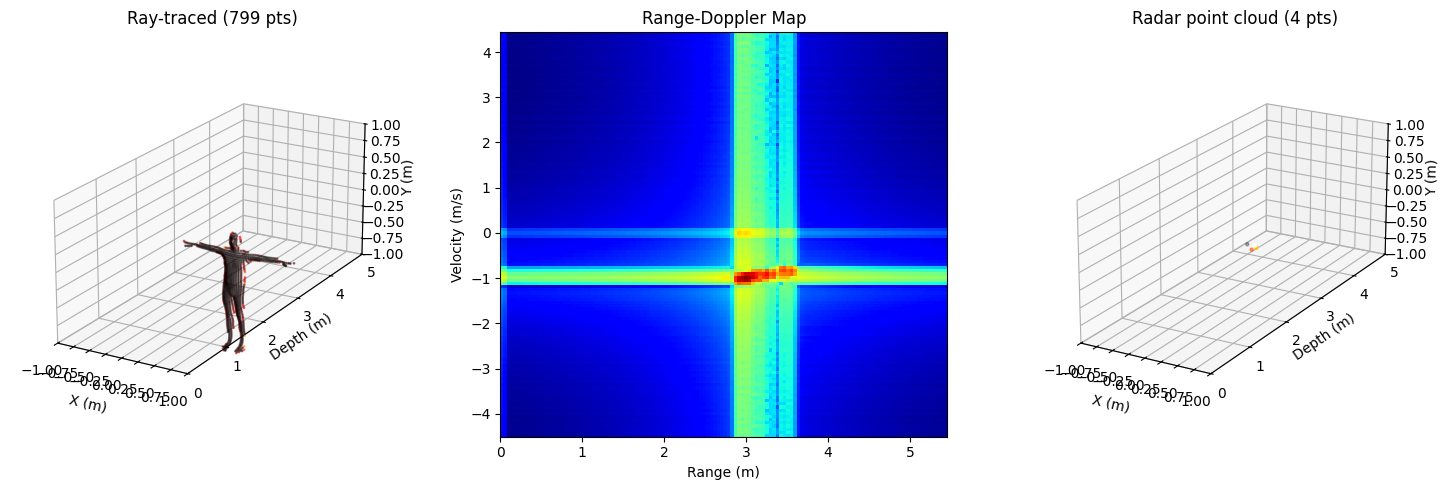

In [11]:
fig = plt.figure(figsize=(15, 5))

# (a) Ray-traced reflection points
ax1 = fig.add_subplot(1, 3, 1, projection='3d')
pts = points.cpu().numpy()
ax1.scatter(pts[:, 0], -pts[:, 2], pts[:, 1],
            c=intensities.cpu().numpy(), cmap='hot', s=1, alpha=0.5)
ax1.set_xlabel('X (m)')
ax1.set_ylabel('Depth (m)')
ax1.set_zlabel('Y (m)')
ax1.set_title(f'Ray-traced ({pts.shape[0]} pts)')
ax1.set_xlim(-1, 1)
ax1.set_ylim(0, 5)
ax1.set_zlim(-1, 1)
ax1.set_box_aspect([1, 2.5, 1])
ax1.view_init(elev=20, azim=-60)

# (b) Range-Doppler map
ax2 = fig.add_subplot(1, 3, 2)
ax2.imshow(
    rd_mag[:, :len(ranges)],
    extent=[ranges[0], ranges[-1], velocities[0], velocities[-1]],
    aspect='auto', origin='lower', cmap='jet',
)
ax2.set_xlabel('Range (m)')
ax2.set_ylabel('Velocity (m/s)')
ax2.set_title('Range-Doppler Map')

# (c) Radar point cloud
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
if pc.shape[0] > 0:
    ax3.scatter(-pc[:, 0], pc[:, 1], pc[:, 2], c=pc[:, 4], cmap='hot', s=5)
ax3.set_xlabel('X (m)')
ax3.set_ylabel('Depth (m)')
ax3.set_zlabel('Y (m)')
ax3.set_title(f'Radar point cloud ({pc.shape[0]} pts)')
ax3.set_xlim(-1, 1)
ax3.set_ylim(0, 5)
ax3.set_zlim(-1, 1)
ax3.set_box_aspect([1, 2.5, 1])
ax3.view_init(elev=20, azim=-60)

plt.tight_layout()